In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

project_path="/content/drive/My Drive/RoadShield-AI"

print(os.listdir(project_path))

['notebooks', 'dataset', 'models', 'outputs', 'docs', 'assets']


used a Roboflow pothole dataset -
https://universe.roboflow.com/aegis/pothole-detection-i00zy/dataset/8

**Export format:** YOLOv8/YOLO

**Uploaded the Dataset to Google Drive**

RoadShield-AI/
│
└── dataset/
      │
      └── pothole_dataset/
             │
             ├── train/
             │      ├── images/
             │      └── labels/
             │
             ├── valid/
             │      ├── images/
             │      └── labels/
             │
             ├── test/
             │      ├── images/
             │      └── labels/
             │
             ├── data.yaml
             └── README.dataset.txt

In [7]:
#Inspect the Dataset

import os

dataset_path="/content/drive/My Drive/RoadShield-AI/dataset/pothole_dataset"

print(os.listdir(dataset_path))

['train', 'valid', 'test', 'README.dataset.txt', 'data.yaml']


In [11]:
#count images
import os

train_images=os.path.join(dataset_path,"train/images")
test_images=os.path.join(dataset_path,"test/images")
valid_images=os.path.join(dataset_path,"valid/images")


print(len(os.listdir(train_images)))
print(len(os.listdir(test_images)))
print(len(os.listdir(valid_images)))


3105
174
273


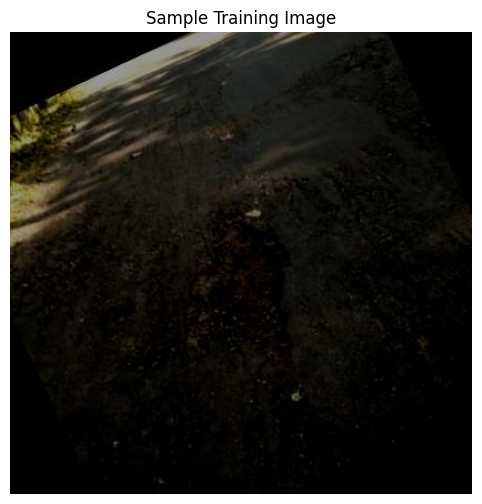

In [19]:
#Display a Sample Image

import cv2
import matplotlib.pyplot as plt
import os

image_path=os.path.join(train_images, os.listdir(train_images)[3100])

image=cv2.imread(image_path)
image=cv2.cvtColor(image,cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10,6))
plt.imshow(image)
plt.axis("off")
plt.title("Sample Training Image")
plt.show()

In [20]:
#Read the Dataset Configuration
import yaml

yaml_path=os.path.join(dataset_path,"data.yaml")

with open(yaml_path,"r") as file:
    config=yaml.safe_load(file)

print(config)

{'train': '../train/images', 'val': '../valid/images', 'test': '../test/images', 'nc': 1, 'names': ['pothole'], 'roboflow': {'workspace': 'aegis', 'project': 'pothole-detection-i00zy', 'version': 8, 'license': 'CC BY 4.0', 'url': 'https://universe.roboflow.com/aegis/pothole-detection-i00zy/dataset/8'}}


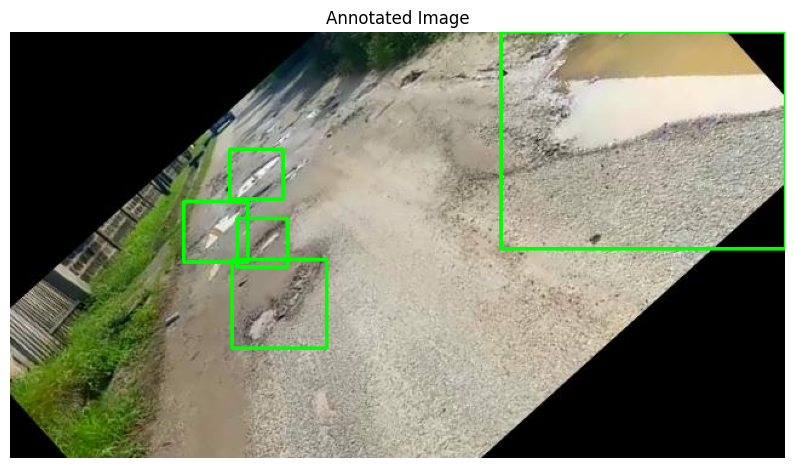

In [25]:
#Visualize an Annotation

import cv2
import matplotlib.pyplot as plt
import os

img_dir=os.path.join(dataset_path,"train/images")
label_dir=os.path.join(dataset_path,"train/labels")

image_name=os.listdir(img_dir)[40]

label_name=image_name.replace(".jpg",".txt")  # Change extension if your images are .png

image=cv2.imread(os.path.join(img_dir,image_name))
h,w,_=image.shape

with open(os.path.join(label_dir,label_name),"r") as file:
    for line in file:
        cls,x,y,bw,bh=map(float,line.split())

        x1=int((x-bw/2)*w)
        y1=int((y-bh/2)*h)

        x2=int((x+bw/2)*w)
        y2=int((y+bh/2)*h)

        cv2.rectangle(image,(x1,y1),(x2,y2),(0,255,0),2)

image=cv2.cvtColor(image,cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10,6))
plt.imshow(image)
plt.axis("off")
plt.title("Annotated Image")
plt.show()

In [28]:
summary = {
    "Training Images": len(os.listdir(os.path.join(dataset_path, "train/images"))),
    "Validation Images": len(os.listdir(os.path.join(dataset_path, "valid/images"))),
    "Test Images": len(os.listdir(os.path.join(dataset_path, "test/images"))),
    "Classes": config["names"]
}

summary

{'Training Images': 3105,
 'Validation Images': 273,
 'Test Images': 174,
 'Classes': ['pothole']}

In [30]:
# to display a dataset summary as a clean table, you can store the information in a Pandas DataFrame

import pandas as pd

# Create dataset summary
dataset_summary = {
    "Category": [
        "Total Images",
        "Training Images",
        "Validation Images",
        "Test Images",
        "Number of Classes",
        "Class Names"
    ],
    "Value": [
        3552,
        3105,
        273,
        174,
        1,
        "Pothole"
    ]
}

# Convert to DataFrame
df = pd.DataFrame(dataset_summary)

# Display
df

,Category,Value
0,Total Images,3552
1,Training Images,3105
2,Validation Images,273
3,Test Images,174
4,Number of Classes,1
5,Class Names,Pothole
